# Scaling

Jusqu'ici, nous avons vu des exemples d'entraînement et d'inférence sur CPU et sur GPU, mais nous n'avons pas abordé le sujet de comment prendre la decision sur l'utilisation d'un type d'équipement ou l'autre. Nous n'avons pas non plus abordé le sujet de quoi faire lorsque notre recherche implique l'utilisation de très gros modèles, tels que les LLMs par exemple. Dans cette section, nous aborderons tous ces sujets: en commencent par les différences entre CPU et GPU, ce que cela implique sur nos grappes, et nous finirons avec des concepts d'entraînement distribué et de calcul parallèle en IA.

Alors, passons directement au sujet des GPUs: Est-ce que tout ce qu'on fait en IA (entraînement ou inférence) va forcement être plus rapide sur un GPU? Est-ce qu'on devrait toujours en utiliser un lorsqu'on en a un disponible? 

Les réponses à ces deux questions sont: **non** et **non**.

Nous verrons dans quelques instants ce qu'est un GPU plus en détail, ce qui répondra à pourquoi la réponse à la première question est **non**. Mais commençons par justifier la réponse à la deuxième, car c'est plus simples et plus important dans le cadre de nos grappes de calcul.

Simplement dit, les GPUs sont BEAUCOUP plus chers et BEAUCOUP moins nombreux que les CPUs sur toutes nos grappes de calcul. Regardez par exemple la différence entre les quantités des deux types de hardware sur la grappe Rorqual par exemple:

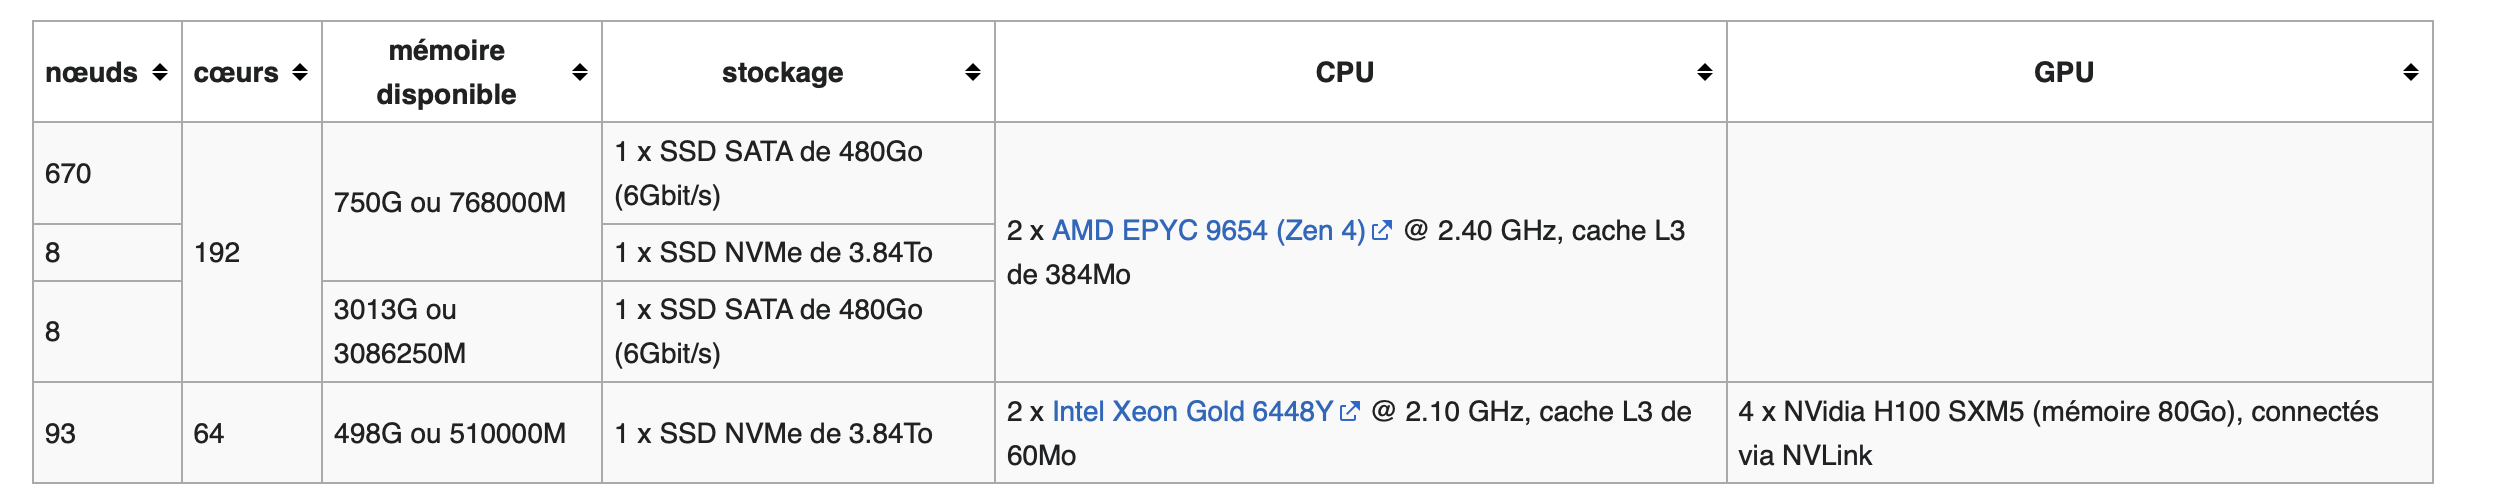


Nous avons plus de 130 mille coeurs CPU versus quelques centaines de GPU sur cette grappe! L'histoire est très semblable sur l'ensemble des grappes de l'Alliance...

Alors, la raison numéro 1 pour preférer les CPU, même si on compte utiliser un grand nombre de ceux-ci, c'est qu'il y a une plus grande disponibilité de ce type d'équipement par rapport aux GPUs.

"Mais les CPUs ne sont-ils moins bons pour les tâches d'IA comme le Deep Learning?"

Il fût un temps où il était vrai qu'entraîner un réseau de neuronnes, ou faire de l'inférence, sur CPU n'était pas vraiment pratique. Mais de nous jours, les CPUs, ainsi que les logiciels de bas niveau comme les librairies d'algébre lineaire, ont BEAUCOUP évolué et ils ne sont plus aussi mauvais en comparaison avec les GPUs! Vous l'avez vu pendant cet atelier où nous avons entraîné un réseau à convolutions avec seulement 2 CPUs.

Sur la grappe rorqual, par exemple, un noeud complet de 192 CPUs livre à peine moins de puissance de calcul qu'un GPU A100, mais avec beaucoup plus de mémoire!!!

Raison numéro deux pour préferer les CPUs: Les grappes de calcul sont un environnement partagé, alors si vous utilisez un GPU, il y a quelqu'un d'autre qui aimerait peut-être l'utiliser, mais ne pourra pas! Si vous n'êtes pas 100% certains d'avoir un avantage à utiliser un GPU versus plusieurs CPUs, passe le tour à quelqu'un qui a peut-être un gros problème de calcul nécessitant un GPU.

Passons maintenant à la question: c'est quoi exactmenet un GPU:

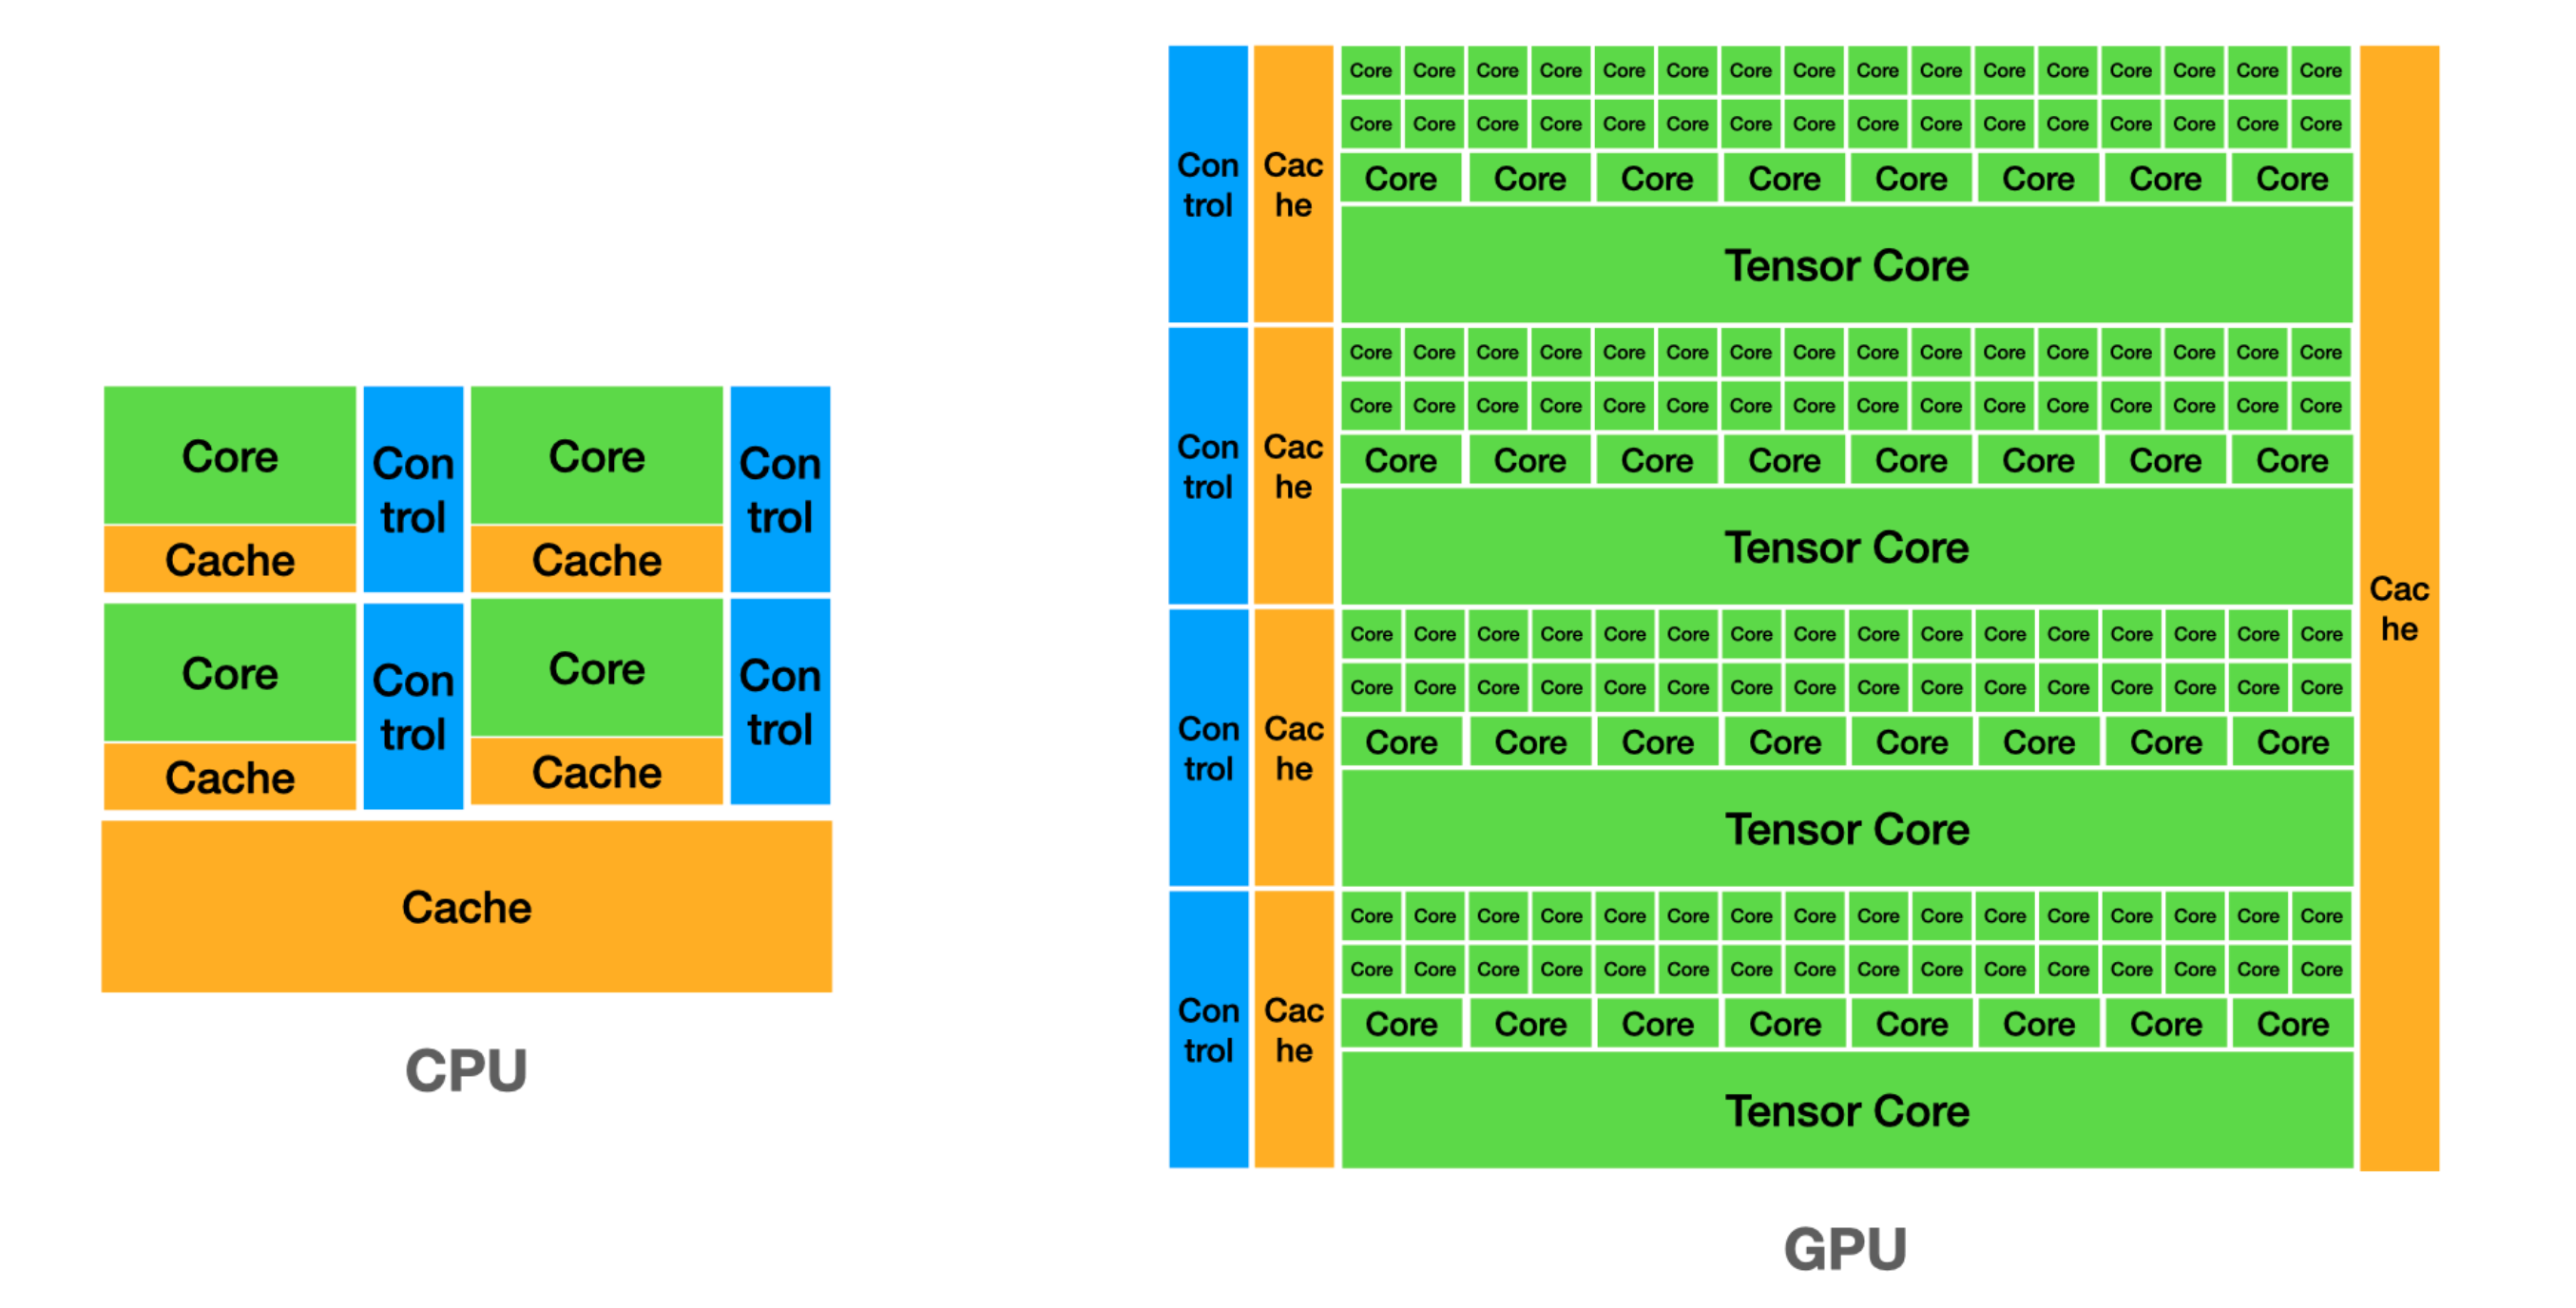


Un GPU est un [processeur massivement parallèle (MPP en anglais)](https://en.wikipedia.org/wiki/Massively_parallel). Il est composé de divers types de coeurs spécialsés, et il possède un très grand nombre de ses coeurs. Par "spécialisé" ici nous voulons dire que ces coeurs sont capables de réaliser un nombre très reduit de types de calcul (instructions) par rapport à ce dont les CPUs sont capables. Rappelez-vous: un CPU doit être capable de tout faire sur un ordinateur en plus de faire des calculs numériques: gérer des écrans, des connexions réseau, la souri, le clavier... et ainsi de suite. Le GPU au contraire doit être très efficace dans le calcul de seulement deux opérations: Multiplier et accumuler.

Ce sont ces deux facteurs qui rendent les GPUs, en moyenne, plus efficaces que les CPUs pour des calculs du type de ceux que nous faisons en IA: produits de vecteurs, produits de matrices... ce ne sont que des multiplications suivi de sommes!

Attention: nous avons bien dit "en moyenne". Pour des problèmes de **très grande taille** l'avantage des GPUs est inquestionnable. Le plus que nous pouvons casser un problème en morceaux (le paralleliser), le plus de coeurs le GPU pourra utiliser pour le calcul et le plus le tout sera accéleré! Cela implique que pour des problèmes de petite taille, vous courrez le risque de simplement ne pas avoir assez de "morceaux" pour occuper tous les coeurs du GPU, et le calcul pourra être plus lent même que le calcul équivalent sur CPU!

### Alors pour en faire un sommaire...

- Commencez **TOUJOURS** par tester votre code IA sur CPU (à moins que le modèle soit TRÈS GRAND). Ajoutez des coeurs et mesurez l'impact sur la performance!
- Les GPU sont des ressources très prisées sur les grappes, et ils y sont présents en moins grand nombre. 
- Rareté + popularité = vous allez attendre plus longtemps!
- Les GPUs de nous jours sont TRÈS GROS en matière de capacité de calcul. Seulement de TRÈS GROS modèles peuvent en tirer tout le jus.


Mais que veut-on dire par très gros? Il y a deux réponses: la règle générale et le "Time-to-science (TTS)".


### Règle générale pour decider si un modèle est assez gros pour un GPU

#### Tâches d'inférence

- Si votre modèle **n'a pas des dizaines de milliards de paramètres**, **vous pouvez utiliser des CPUs** (1 demi-noeud complet sur Rorqual est plus que suffisant)

#### Tâches d'entraînement
- Si votre modèle **n'a pas des centaines de millions de paramètres**, **vous pouvez utiliser des CPUs** (1 demi-noeud complet sur Rorqual est plus que suffisant)

### Utiliser le Time-to-science (TTS) pour décider

Le TTS est le temps que ça prend pour aller de la soumission de votre job jusqu'à l'obtention des résultats. Il y a deux facteurs majeurs qui rentrent dans le calcul du TTS: le **temps d'attente** de la job et le **temps d'exécution** de la job.

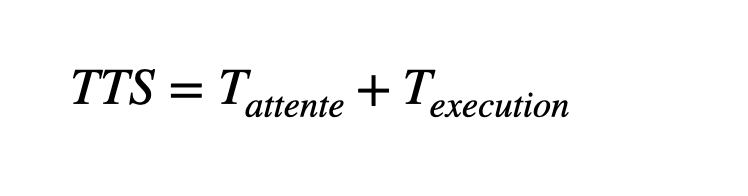

Nous aimerions minimiser le TTS.


Utiliser des CPUs plutôt que des GPUs diminue le temps d'attente (il y a plus de CPUs que de GPUs sur les grappes), mais peut augmenter le temps d'exécution.

La marche a suivre est donc: faites une "dry run" de votre code. Cette étape de teste derait être une mini-version de votre vraie tâche: peu de données, 1 seule époque d'entraînement. Testez votre code et extrapolez ce que ça donnerait avec la vraie tâche. Ajoutez des CPUs au test jusqu'à ce que l'estimée de TTS pour la vraie tâche soit acceptable.

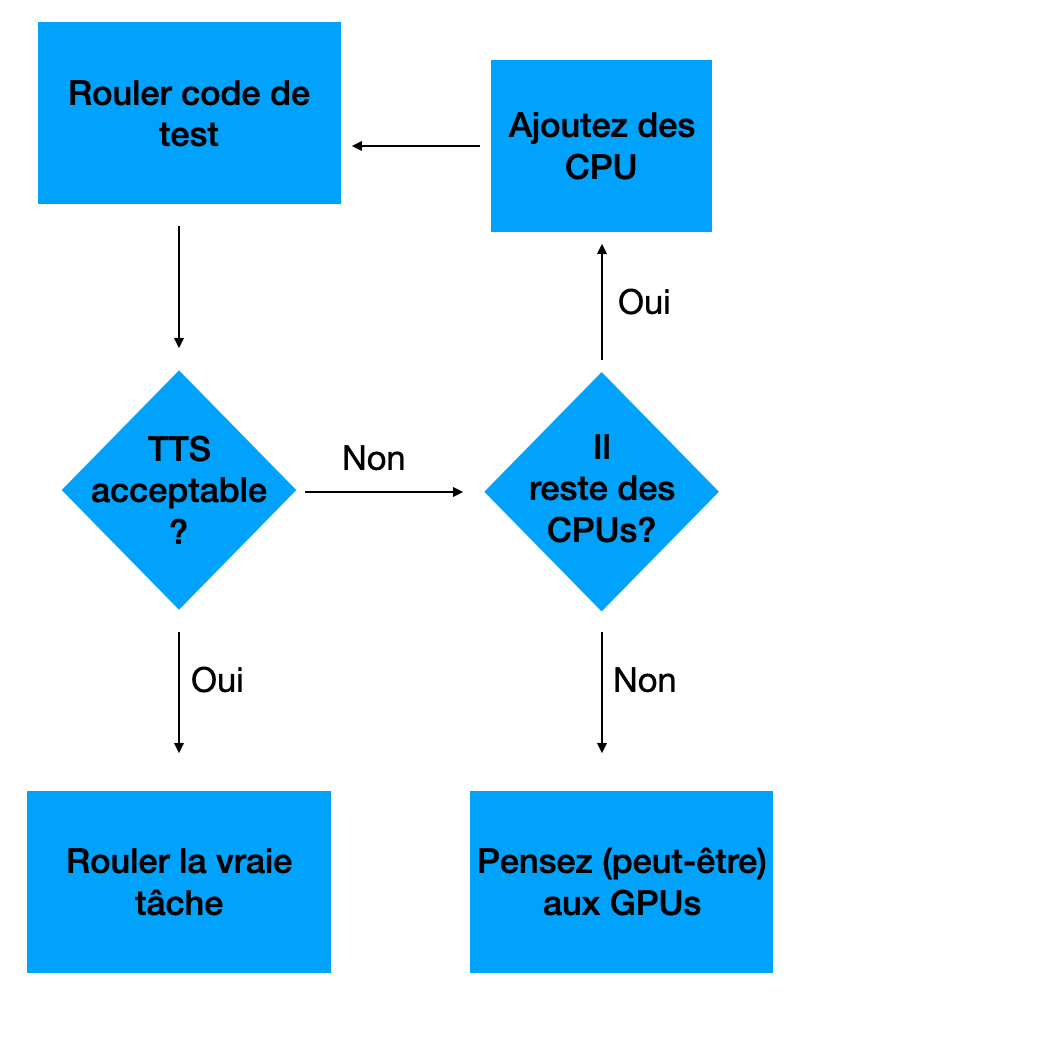

Bien évidemment, le concept de TTS *acceptable* est subjectif. Peut-être vous avez une conférence qui approche, ou vous devez déposer un paper le lendemain et vous n'avez pas encore tout réussi à faire. Dans ces cas, le seuil du TTS acceptable risque d'être plutôt bas...

Dans ces cas, penser à utiliser des GPUs devient une option. Nous avons mentionné auparavant que nos grappes disposent de TRÈS GROS GPUs, dont seulement de très gros modèles peuvent en faire une utilisation optimale. Ce que nous avons omis jusqu'à maintenant, c'est que nous offrons aussi des **partitions** de ces gros GPUs, c'est à dire, vous pouve demander une portion d'un GPU dans votre tâche si vous ne croyez pas avoir besoin d'un au complet!

La marche a suivre devient donc: vérifiez les besoins en mémoire de votre tâche. Si les besoins sont plus bas que la mémoire d'un GPU au complet, allez avec une partition, sinon, allez avec le GPU au complet.

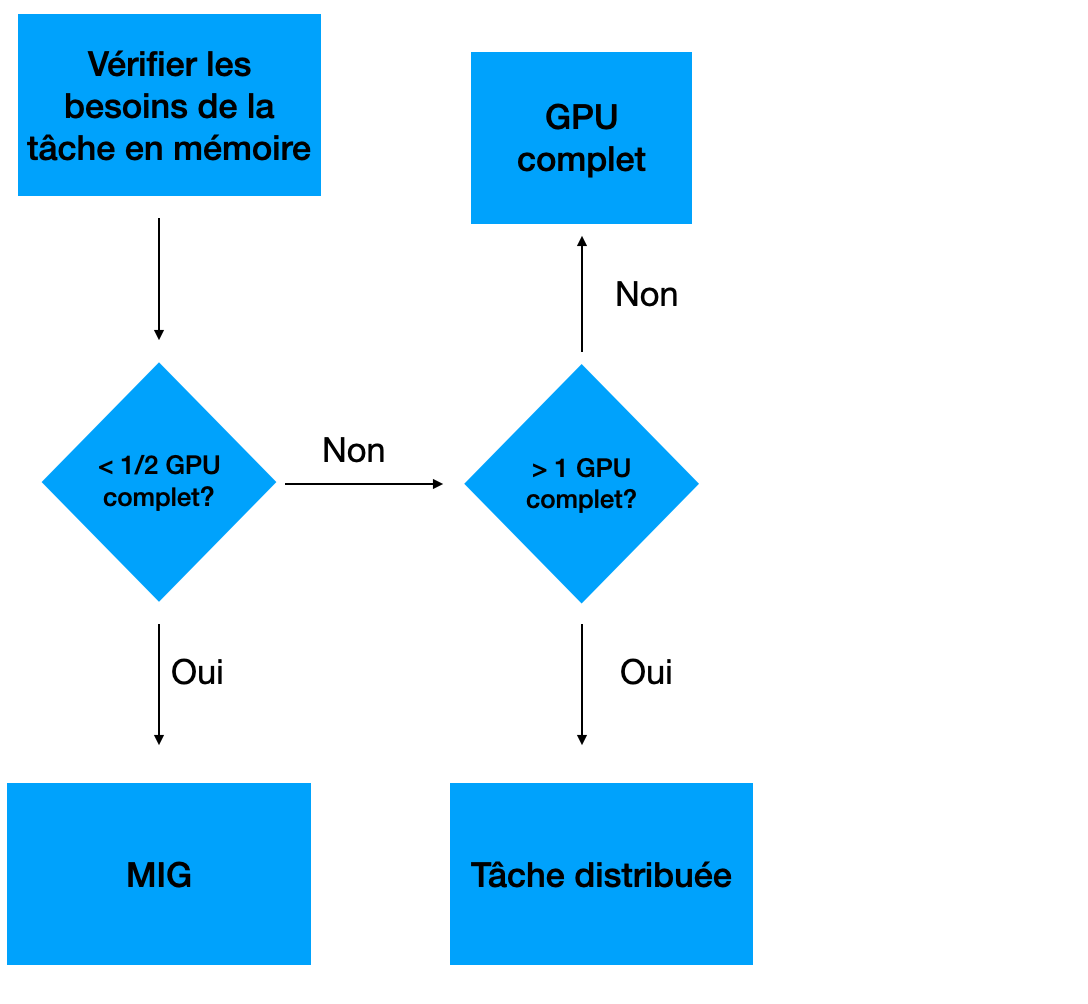

Il y a un nombre de **partitions MIG** de differentes tailles disponibles sur les grappes. Consultez la [documentation](https://docs.alliancecan.ca/wiki/Multi-Instance_GPU) pour plus de détails.

Il nous reste un dernier sujet à aborder: les tâches distribuées, ou quoi faire quand ma tâche ne rentre pas dans un seul GPU.

## Entraînement distribué

Il existe un grand nombre de types de tâche distribuée en IA. Ici, nous utiliserons l'entraînement de modèles pour illustrer les concepts du parallelisme multi-device car ils restent les mêmes peu importe le type de tâche que vous avez entre les mains. Nous parlerons ici de:
 
 - Parallelisme de données
 - Parallelisme "Fully Sharded"
 
Ce sont des manières differentes d'aborder les problèmes de grande taille. Dans le cas de la première, c'est le bon choix lorsque votre problème inclut un TRÈS GROS jeu de données. Cela veeut dire que, peu importe la taille de votre modèle en tant que tel, l'entonnoir dans votre tâche c'est la quantité de données que vous avez à passer dans le modèle. Dans le cas de la deuxième, l'entonnoir est la taille du modèle: il ne rentre pas dans la mémoire d'un seul GPU.

### Le parallelisme de données

Nous avons dit ci-haut que le parallelisme de données est une technique à privilegier lorsque nous avons un très grand ensemble de données. Cela n'est pas tout à fait correct. En vérité, le parallelisme de données peut être utilisée n'importe quand pour accelérer un calcul, lorsque le calcul en question peut être appliqué en parallèle à plusieurs sous-ensembles de données de façon indépendente. En d'autres mots, si votre problème de calcul vous permet de le diviser en plusieurs morceaux indépendents, où vous appliquerez les mêmes opérations dans chaque morceau, vous pouvez utiliser le parallelisme de données pour faire ce calcul N fois plus vite, où N est le nombre de morceaux.

En Pytorch, le module Distributed Data Parallel (DDP) implemente cette approche pour l'entraînement de modèles IA.

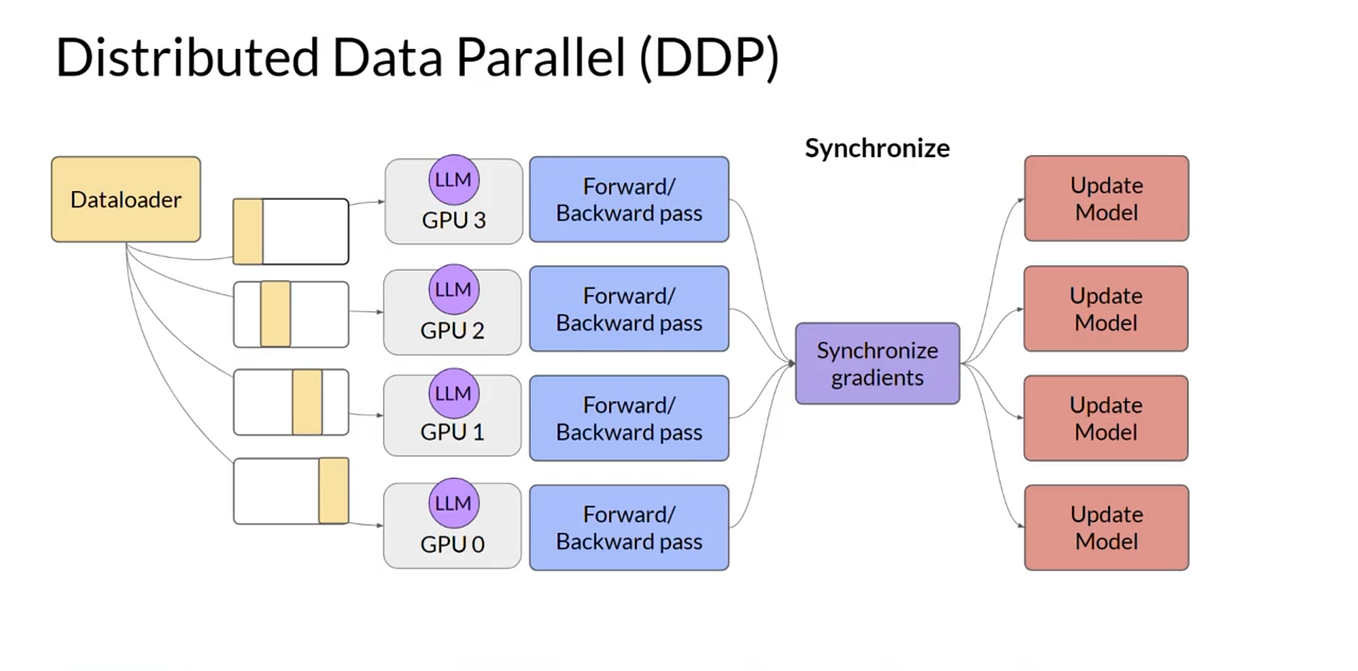

En gros, l'approche consiste à créer des "copies" du modèle que nous voulons entraîner, et de montrer à chaque copie seulement un sous-ensemble du jeu de données d'entraînement. Une fois les étapes de forward et backpropagation que nous connaissons sont faites, les gradients calculées dans chaque copie sont rassemblés et une aggregation est calculée - cela peut être la moyenne, la médianne, la somme... l'important est d'avoir un seul vecteur de gradients au lieu de plusieurs. C'est ce vecteur qui est en suite repassé à toutes les copies, et le même update de paramètres est fait partout en même temps.

Voici le code Pytorch pour utiliser DDP sur nos grappes:

```bash
#!/bin/bash
#SBATCH --nodes 1             
#SBATCH --gres=gpu:2          # Request 2 GPU "generic resources”.
#SBATCH --tasks-per-node=2   # Request 1 process per GPU. You will get 1 CPU per process by default. Request more CPUs with the "cpus-per-task" parameter to enable multiple data-loader workers to load data in parallel.
#SBATCH --mem=8G      
#SBATCH --time=0-03:00
#SBATCH --output=%N-%j.out

module load python # Using Default Python version - Make sure to choose a version that suits your application
srun -N $SLURM_NNODES -n $SLURM_NNODES bash << EOF
virtualenv --no-download $SLURM_TMPDIR/env
source $SLURM_TMPDIR/env/bin/activate
pip install torch torchvision --no-index
EOF

export TORCH_NCCL_ASYNC_HANDLING=1
export MASTER_ADDR=$(hostname) #Store the master node’s IP address in the MASTER_ADDR environment variable.

echo "r$SLURM_NODEID master: $MASTER_ADDR"
echo "r$SLURM_NODEID Launching python script"

# The $((SLURM_NTASKS_PER_NODE * SLURM_JOB_NUM_NODES)) variable tells the script how many processes are available for this execution. “srun” executes the script <tasks-per-node * nodes> times

source $SLURM_TMPDIR/env/bin/activate

srun python pytorch-ddp-test.py --init_method tcp://$MASTER_ADDR:3456 --world_size $((SLURM_NTASKS_PER_NODE * SLURM_JOB_NUM_NODES))  --batch_size 256
```

---

```python
import os
import time
import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.backends.cudnn as cudnn

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

import torch.distributed as dist
import torch.utils.data.distributed

import argparse

parser = argparse.ArgumentParser(description='cifar10 classification models, distributed data parallel test')
parser.add_argument('--lr', default=0.1, help='')
parser.add_argument('--batch_size', type=int, default=768, help='')
parser.add_argument('--max_epochs', type=int, default=4, help='')
parser.add_argument('--num_workers', type=int, default=0, help='')

parser.add_argument('--init_method', default='tcp://127.0.0.1:3456', type=str, help='')
parser.add_argument('--dist-backend', default='nccl', type=str, help='')
parser.add_argument('--world_size', default=1, type=int, help='')
parser.add_argument('--distributed', action='store_true', help='')

def main():
    print("Starting...")

    args = parser.parse_args()

    local_rank = int(os.environ.get("SLURM_LOCALID")) 
    rank = int(os.environ.get("SLURM_PROCID"))
    current_device = local_rank

    torch.cuda.set_device(current_device)

    """ this block initializes a process group and initiate communications
		between all processes running on all nodes """

    print('From Rank: {}, ==> Initializing Process Group...'.format(rank))
    #init the process group
    dist.init_process_group(backend=args.dist_backend, init_method=args.init_method, world_size=args.world_size, rank=rank)
    print("process group ready!")

    print('From Rank: {}, ==> Making model..'.format(rank))

    class Net(nn.Module):

       def __init__(self):
          super(Net, self).__init__()

          self.conv1 = nn.Conv2d(3, 6, 5)
          self.pool = nn.MaxPool2d(2, 2)
          self.conv2 = nn.Conv2d(6, 16, 5)
          self.fc1 = nn.Linear(16 * 5 * 5, 120)
          self.fc2 = nn.Linear(120, 84)
          self.fc3 = nn.Linear(84, 10)

       def forward(self, x):
          x = self.pool(F.relu(self.conv1(x)))
          x = self.pool(F.relu(self.conv2(x)))
          x = x.view(-1, 16 * 5 * 5)
          x = F.relu(self.fc1(x))
          x = F.relu(self.fc2(x))
          x = self.fc3(x)
          return x

    net = torch.compile(Net())

    net.cuda()
    net = torch.nn.parallel.DistributedDataParallel(net, device_ids=[current_device])

    print('From Rank: {}, ==> Preparing data..'.format(rank))

    transform_train = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    dataset_train = CIFAR10(root='./data', train=True, download=False, transform=transform_train)

    train_sampler = torch.utils.data.distributed.DistributedSampler(dataset_train)
    train_loader = DataLoader(dataset_train, batch_size=args.batch_size, shuffle=(train_sampler is None), num_workers=args.num_workers, sampler=train_sampler, pin_memory=True)

    criterion = nn.CrossEntropyLoss().cuda()
    optimizer = optim.SGD(net.parameters(), lr=args.lr, momentum=0.9, weight_decay=1e-4)

    for epoch in range(args.max_epochs):

        train_sampler.set_epoch(epoch)

        train(epoch, net, criterion, optimizer, train_loader, rank)

def train(epoch, net, criterion, optimizer, train_loader, train_rank):

    epoch_start = time.time()

    for batch_idx, (inputs, targets) in enumerate(train_loader):

       start = time.time()

       inputs = inputs.cuda()
       targets = targets.cuda()
       outputs = net(inputs)
       loss = criterion(outputs, targets)

       optimizer.zero_grad()
       loss.backward()
       optimizer.step()

       batch_time = time.time() - start

       elapse_time = time.time() - epoch_start
       elapse_time = datetime.timedelta(seconds=elapse_time)
       print("From Rank: {}, Training time {}".format(train_rank, elapse_time))

if __name__=='__main__':
   main()
```

### Parallelisme de données "Fully Sharded"

Le parallelisme de données "Fully Sharded" est un mélange entre deux types de parallelisme: le parallelisme de données, que nous venons de voir, et le parallelisme de tenseurs, que nous ne verrons pas en détail ici. Le parallelisme de tenseurs consite à "casser" le modèle en morceaux, de manière à ce que chaque morceau soit placé dans son propre GPU. Les morceaux ne sont pas placés dans les GPUs en séquences du genre Couche 1 à 10 dans GPU 0, Couche 11 à 20 dans GPU 1 et ainsi de suite. Ce genre de parallelisme s'appelle parallelisme de Pipelines, et nous n'en parlerons pas ici. Dans le parallelisme de tenseurs, les poids d'une même couche peuvent atterir dans des GPUs differents. Voilà tout ce que nous avons à dire sur ce sujet ici. Cette partie est importante, car c'est ce que le parallelisme "Fully Sharded" fait aussi:

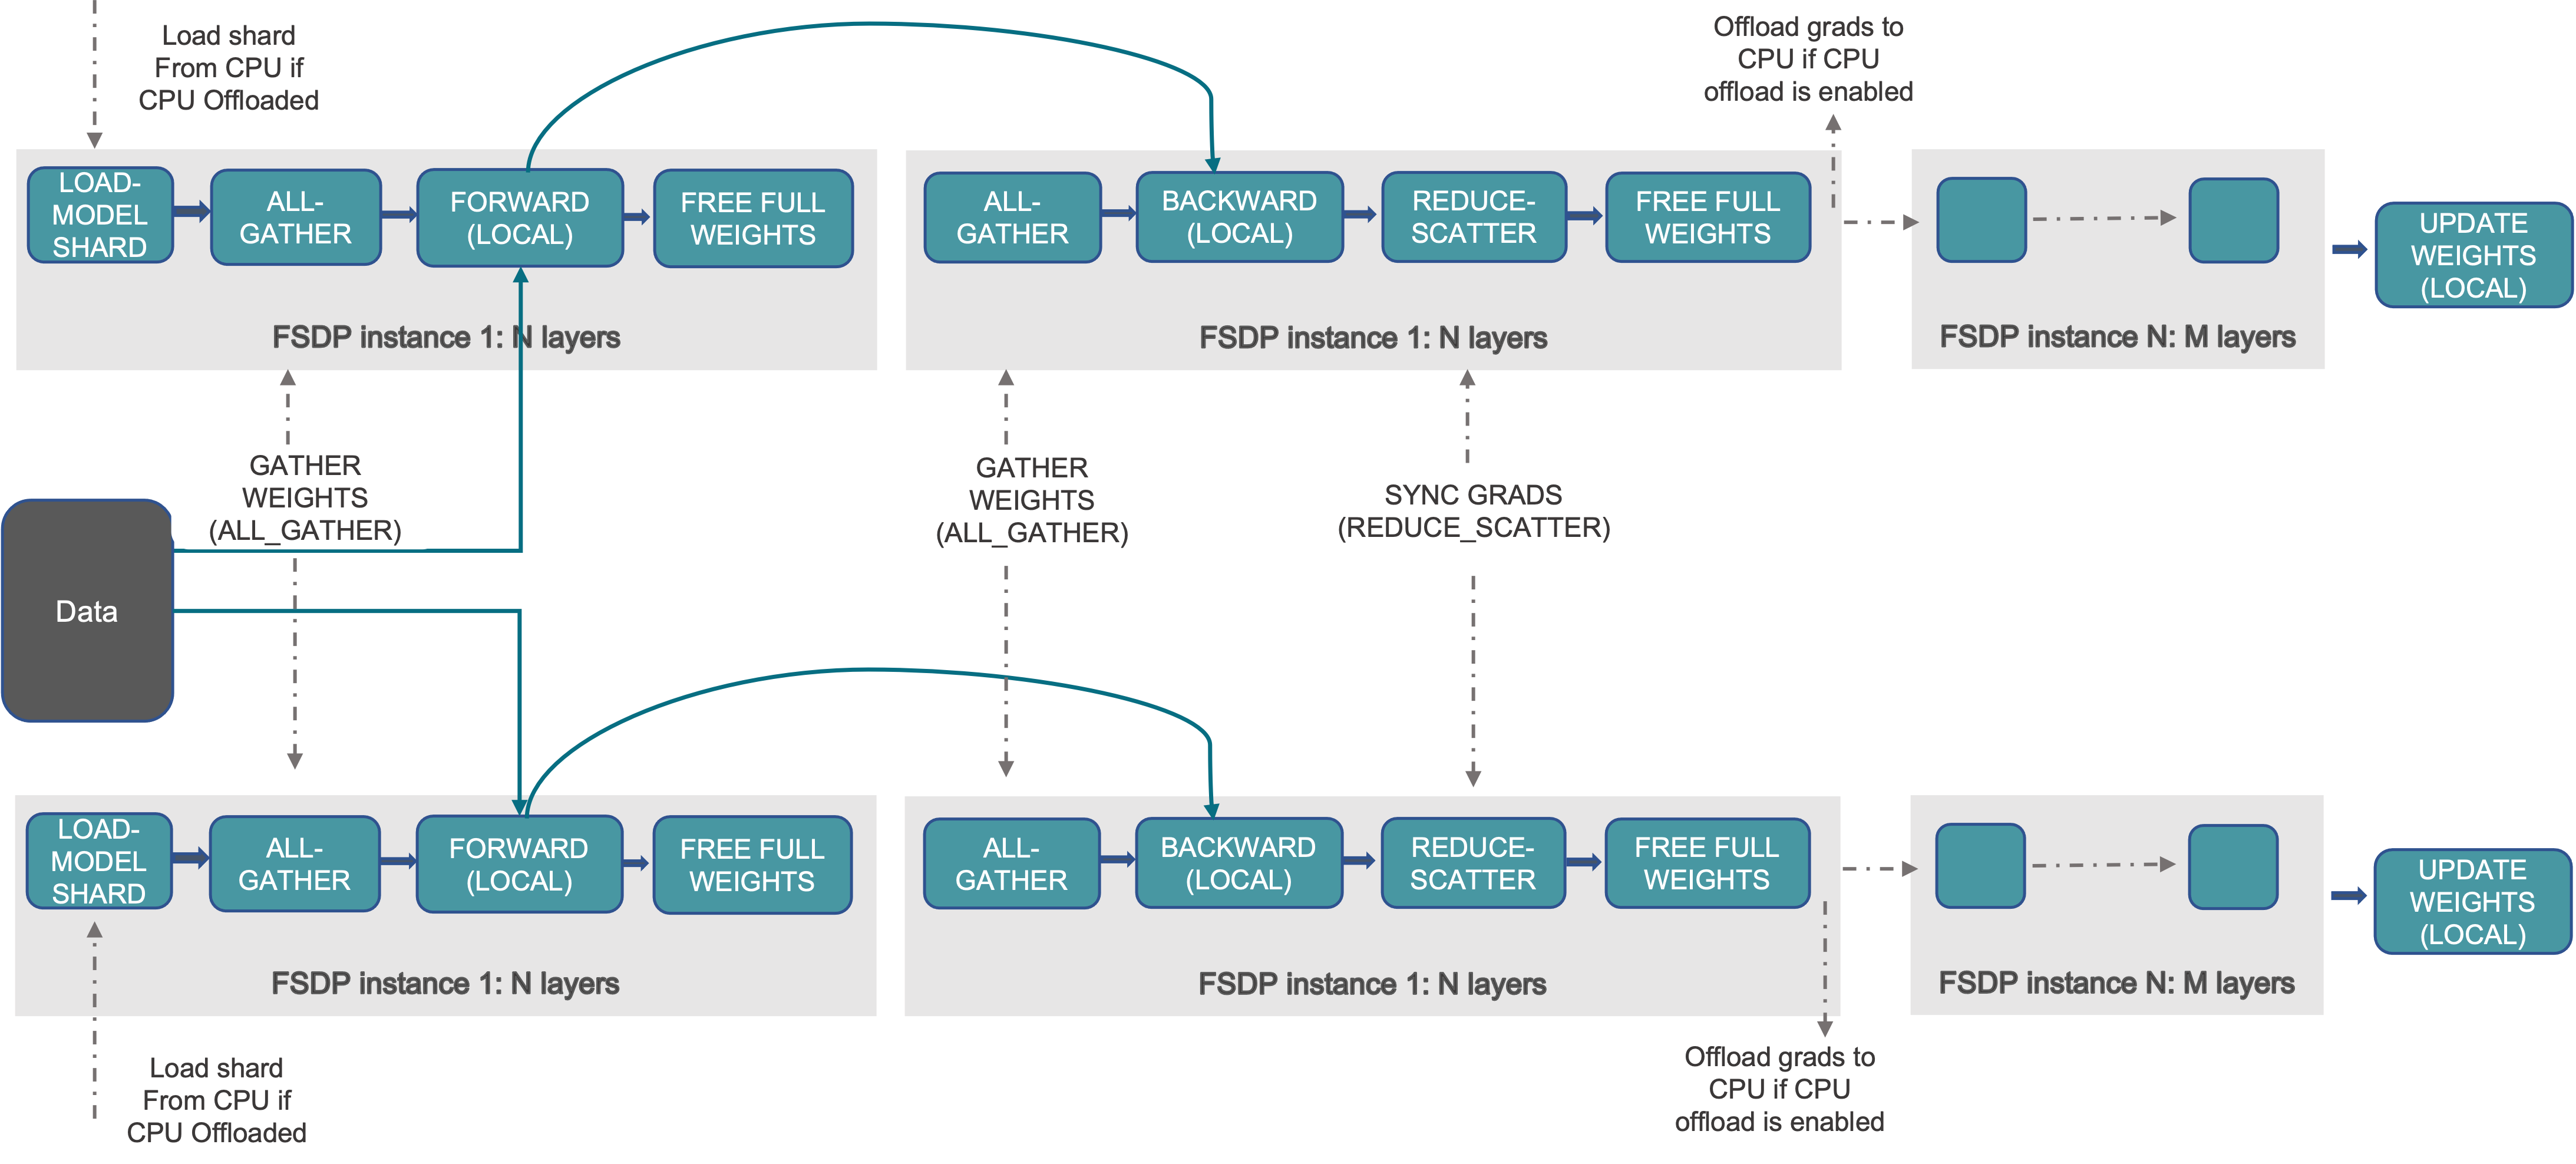

De cette manière, nous avons les bienfaits du parallelisme de données (plusieurs sous-ensembles du jeu de données passent par le modèle en même temps), et ceux du parallelisme de tenseurs (le modèle complet peut être plus gros que la mémoire d'un seul GPU).

Le code qui suit est un exemple simplifié de comment entraîner un modèle avec du parallelisme "Fully Sharded" sur nos grappes. Nous utilisons le paquet <code>accelerate</code> pour envelopper un modèle avec la classe <code>FSDP</code> automatiquement au lieu d'écrire le code pour le faire en PyTorch nous-mêmes. Dans cet exemple, nous entraînons un LLM à 7 milliards de paramètres avec 4 GPUs:

```bash
#!/bin/bash
#SBATCH --nodes 1
#SBATCH --ntasks-per-node=1
#SBATCH --gres=gpu:4
#SBATCH --cpus-per-task=48 
#SBATCH --mem=0       
#SBATCH --time=0-00:30:00
#SBATCH --output=%N-%j.out

module load python/3.11 gcc arrow

virtualenv --no-download $SLURM_TMPDIR/ENV
source $SLURM_TMPDIR/ENV/bin/activate

pip install --upgrade pip --no-index
pip install --no-index transformers datasets trl accelerate

cp -r ultrachat_dataset $SLURM_TMPDIR/ #copy the dataset to local storage

export HF_DATASETS_CACHE=$SLURM_TMPDIR/ultrachat_dataset 
export TRANSFORMERS_CACHE=./zephyr-7b-beta

export HF_DATASETS_OFFLINE=1
export TRANSFORMERS_OFFLINE=1

export TORCH_NCCL_ASYNC_ERROR_HANDLING=1

accelerate launch \
—-config_file="fsdp.yaml" \ 
--mixed_precision="fp16" \ 
--num_machines=$SLURM_NNODES \
--machine_rank=$SLURM_NODEID \
--num_processes=4 \
train_llm.py
```
---

```yaml
compute_environment: LOCAL_MACHINE
debug: true
distributed_type: FSDP
downcast_bf16: 'no'
fsdp_config:
  fsdp_auto_wrap_policy: TRANSFORMER_BASED_WRAP
  fsdp_backward_prefetch: BACKWARD_PRE
  fsdp_cpu_ram_efficient_loading: true
  fsdp_forward_prefetch: true
  fsdp_offload_params: false
  fsdp_sharding_strategy: FULL_SHARD
  fsdp_state_dict_type: SHARDED_STATE_DICT
  fsdp_sync_module_states: true
  fsdp_use_orig_params: true
machine_rank: 0
main_training_function: main
num_machines: 1
num_processes: 4
rdzv_backend: static
same_network: true
tpu_env: []
tpu_use_cluster: false
tpu_use_sudo: false
use_cpu: false
```

---

```python
import transformers
from transformers import MistralForCausalLM, AutoTokenizer
from transformers import TrainingArguments

from datasets import load_dataset
from datasets import DatasetDict

from accelerate import Accelerator

from trl import SFTTrainer


accelerator = Accelerator()

def main():

   dataset = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_gen")

   tokenizer = AutoTokenizer.from_pretrained("./zephyr-7b-beta",local_files_only=True)

   tokenizer.pad_token = tokenizer.eos_token

   model = MistralForCausalLM.from_pretrained("./zephyr-7b-beta",local_files_only=True)

   def preprocess(samples):
      batch = []
      for conversation in samples["messages"]:
         batch.append(tokenizer.apply_chat_template(conversation, tokenize=False))
      return {"content": batch}

   training_set=DatasetDict()

   training_set["train"] = dataset.map(preprocess,
            batched=True,
             remove_columns=dataset.column_names
            )

   trainer = SFTTrainer(
     model=model,
     train_dataset=training_set["train"],
     tokenizer=tokenizer,
     packing=True,
     dataset_text_field="content",
     max_seq_length=2048,
     args=transformers.TrainingArguments(
        output_dir="./",
        per_device_train_batch_size=8,
        gradient_accumulation_steps=1,
        gradient_checkpointing=True,
        max_steps=15,
        logging_steps=1,
        learning_rate=2.5e-5,
        optim="adamw_torch",
        logging_dir="./logs",        # Directory for storing logs
        remove_unused_columns=False,
     ),
   )

   trainer.train()

   accelerator.wait_for_everyone()


if __name__=='__main__':
   main()
```